# Predicción de Informalidad Laboral en Colombia: Análisis Exploratorio

---
### Setup y carga de dataset

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

# Parquet generado por 1.Ingesta.ipynb
RUTA_PARQUET = Path('parquet/geih_2025_crudo.parquet')

df = pd.read_parquet(RUTA_PARQUET)

print('Dataset cargado')
print(f'   Filas:    {len(df):,}')
print(f'   Columnas: {df.shape[1]}')
print(f'   Memoria:  {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print(f'   Columnas: {list(df.columns)}')

Dataset cargado
   Filas:    358,029
   Columnas: 21
   Memoria:  57.4 MB
   Columnas: ['DIRECTORIO', 'SECUENCIA_P', 'ORDEN', 'CLASE', 'FEX_C18', 'DPTO', 'P3271', 'P6040', 'P6070', 'P3042', 'P3042S1', 'P6450', 'P6460', 'P6430', 'P6800', 'P3069', 'P6920', 'P7040', 'INGLABO', 'RAMA2D_R4', 'INFORMAL']


---
### Estructura, tipología y valores nulos

In [78]:
print('Datatypes')
print(df.dtypes.to_string())

print('\nMuestra')
df.head()

nulos = pd.DataFrame({
    'n_nulos':   df.isna().sum(),
    'pct_nulos': (df.isna().sum() / len(df) * 100).round(2)
}).sort_values('pct_nulos', ascending=False)

print('Valores nulos por columna')
print(nulos.to_string())

Datatypes
DIRECTORIO       int64
SECUENCIA_P      int64
ORDEN            int64
CLASE            int64
FEX_C18        float64
DPTO             int64
P3271            int64
P6040            int64
P6070          float64
P3042          float64
P3042S1        float64
P6450          float64
P6460          float64
P6430            int64
P6800            int64
P3069            int64
P6920            int64
P7040            int64
INGLABO        float64
RAMA2D_R4        int64
INFORMAL       float64

Muestra
Valores nulos por columna
             n_nulos  pct_nulos
P6460         217611      60.78
P6450         142449      39.79
INGLABO         8199       2.29
INFORMAL        6308       1.76
RAMA2D_R4          0       0.00
P7040              0       0.00
P6920              0       0.00
P3069              0       0.00
P6800              0       0.00
P6430              0       0.00
DIRECTORIO         0       0.00
SECUENCIA_P        0       0.00
P3042              0       0.00
P6070              0    

Las características con más valores nulos:

P6460 -> 217611 = 60.78%

P6450 -> 142449 = 39.79%

INGLABO -> 8199 = 2.29%

INFORMAL -> 6308 = 1.76%

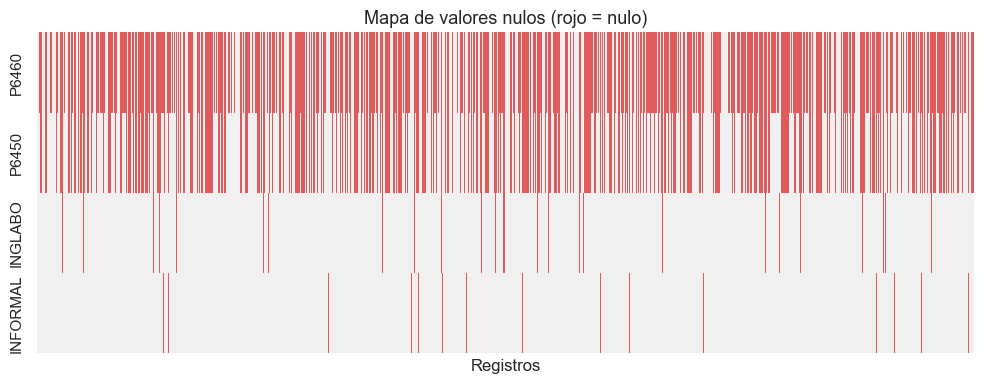

In [79]:
# Visualización: mapa de calor de nulos
cols_con_nulos = nulos[nulos['n_nulos'] > 0].index.tolist()

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    df[cols_con_nulos].isna().T,
    cbar=False, yticklabels=True, xticklabels=False,
    cmap=['#f0f0f0', '#e05c5c'], ax=ax
)
ax.set_title('Mapa de valores nulos (rojo = nulo)', fontsize=13)
ax.set_xlabel('Registros')
plt.tight_layout()
plt.show()


---
### Distribución de variable objetivo `INFORMAL`

Registros con INFORMAL definido: 351,721
  Informales (1): 200,796  (57.1%)
  Formales   (0): 150,925  (42.9%)
  Ratio:          1.33:1

Tasa de informalidad ponderada (FEX_C18): 56.0%
(esta es la cifra comparable a los boletines oficiales del DANE)


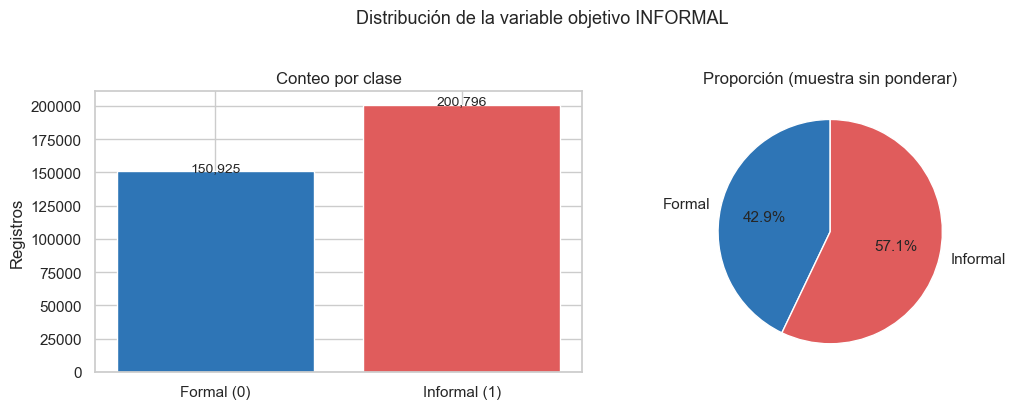

In [80]:
# Solo registros con INFORMAL definido (excluye pensionados y nulos)
df_validos = df[df['INFORMAL'].notna()].copy()

n_total    = len(df_validos)
n_informal = (df_validos['INFORMAL'] == 1).sum()
n_formal   = (df_validos['INFORMAL'] == 0).sum()

print(f'Registros con INFORMAL definido: {n_total:,}')
print(f'  Informales (1): {n_informal:,}  ({n_informal/n_total*100:.1f}%)')
print(f'  Formales   (0): {n_formal:,}  ({n_formal/n_total*100:.1f}%)')
print(f'  Ratio:          {n_informal/n_formal:.2f}:1')

# Tasa ponderada por FEX_C18 (representativa a nivel nacional)
tasa_ponderada = (
    (df_validos['INFORMAL'] * df_validos['FEX_C18']).sum() /
    df_validos['FEX_C18'].sum() * 100
)
print(f'\nTasa de informalidad ponderada (FEX_C18): {tasa_ponderada:.1f}%')
print('(esta es la cifra comparable a los boletines oficiales del DANE)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

conteos = df_validos['INFORMAL'].value_counts().sort_index()
axes[0].bar(['Formal (0)', 'Informal (1)'], conteos.values,
            color=['#2E75B6', '#E05C5C'], edgecolor='white')
axes[0].set_title('Conteo por clase')
axes[0].set_ylabel('Registros')
for i, v in enumerate(conteos.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontsize=10)

axes[1].pie(
    [n_formal/n_total, n_informal/n_total],
    labels=['Formal', 'Informal'],
    colors=['#2E75B6', '#E05C5C'],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 11}
)
axes[1].set_title('Proporción (muestra sin ponderar)')

plt.suptitle('Distribución de la variable objetivo INFORMAL', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
### Informalidad por departamento

Fuente de códigos de departamento: https://www.fopep.gov.co/sheempoo/2019/02/Tabla-C%C3%B3digos-Dane.pdf

In [81]:
# Top departamentos por tasa de informalidad (ponderada)
tasa_dpto = (
    df_validos[df_validos["DPTO"].notna()]
    .groupby("DPTO", observed=True)
    .apply(lambda g: (
        (g["INFORMAL"] * g["FEX_C18"]).sum() / g["FEX_C18"].sum() * 100
    ), include_groups=False)
    .reset_index()
    .rename(columns={0: "tasa"})
    .sort_values("tasa", ascending=True)
)

print(f"Departamentos en los datos: {tasa_dpto['DPTO'].nunique()}")
print(f"Rango de tasas: {tasa_dpto['tasa'].min():.1f}% — {tasa_dpto['tasa'].max():.1f}%")

nombres_dpto = {
     5: 'Antioquia',          8: 'Atlántico',        11: 'Bogotá',
    13: 'Bolívar',           15: 'Boyacá',           17: 'Caldas',
    18: 'Caquetá',           19: 'Cauca',            20: 'Cesar',
    23: 'Córdoba',           25: 'Cundinamarca',     27: 'Chocó',
    41: 'Huila',             44: 'La Guajira',       47: 'Magdalena',
    50: 'Meta',              52: 'Nariño',           54: 'N. de Santander',
    63: 'Quindío',           66: 'Risaralda',        68: 'Santander',
    70: 'Sucre',             73: 'Tolima',           76: 'Valle del Cauca',
    81: 'Arauca',            85: 'Casanare',         86: 'Putumayo',
    88: 'San Andrés',        91: 'Amazonas',         94: 'Guainía',
    95: 'Guaviare',          97: 'Vaupés',           99: 'Vichada',
}

tasa_dpto['nombre'] = tasa_dpto['DPTO'].map(nombres_dpto).fillna('Cód. ' + tasa_dpto['DPTO'].astype(str))

fig = px.bar(
    tasa_dpto, x="tasa", y='nombre', orientation="h",
    title="Tasa de informalidad por departamento (ponderada por FEX_C18)",
    labels={"tasa": "Tasa de informalidad (%)", "nombre": "Departamento"},
    color="tasa", color_continuous_scale="RdYlGn_r",
    height=800
)
fig.update_layout(coloraxis_showscale=False)
fig.show()


Departamentos en los datos: 33
Rango de tasas: 26.0% — 84.3%


---
### Informalidad por nivel educativo (`P3042`)

Esperamos una relación negativa: a mayor educación, menor informalidad.

In [82]:
labels_edu = {
    1: 'Ninguno', 2: 'Preescolar', 3: 'Primaria inc.',
    4: 'Primaria', 5: 'Secundaria inc.', 6: 'Secundaria',
    7: 'Media inc.', 8: 'Media', 9: 'Técnica/Tecn.',
    10: 'Universitaria', 11: 'Especialización',
    12: 'Maestría', 13: 'Doctorado'
}

df_validos['EDU_LABEL'] = df_validos['P3042'].map(labels_edu)

tasa_edu = (
    df_validos[df_validos['P3042'].notna()]
    .groupby('P3042', observed=True)
    .apply(lambda g: (
        (g['INFORMAL'] * g['FEX_C18']).sum() / g['FEX_C18'].sum() * 100
    ), include_groups=False)
    .reset_index()
    .rename(columns={0: 'tasa'})
)
tasa_edu['etiqueta'] = tasa_edu['P3042'].map(labels_edu)

fig = px.bar(
    tasa_edu, x='etiqueta', y='tasa',
    title='Tasa de informalidad por nivel educativo (ponderada)',
    labels={'etiqueta': 'Nivel educativo', 'tasa': 'Tasa de informalidad (%)'},
    color='tasa',
    color_continuous_scale='RdYlGn_r',
    text=tasa_edu['tasa'].round(1).astype(str) + '%'
)
fig.update_traces(textposition='outside')
fig.update_layout(coloraxis_showscale=False, xaxis_tickangle=-45)
fig.show()

---
### Informalidad por posición ocupacional (`P6430`)

In [83]:
labels_posicion = {
    1: 'Empleado particular',
    2: 'Empleado gobierno',
    3: 'Empleado doméstico',
    4: 'Cuenta propia',
    5: 'Patrón / empleador',
    6: 'Trab. familiar s/remuneración',
    7: 'Jornalero / peón',
    8: 'Otro',
}

tasa_pos = (
    df_validos[df_validos['P6430'].notna()]
    .groupby('P6430', observed=True)
    .apply(lambda g: (
        (g['INFORMAL'] * g['FEX_C18']).sum() / g['FEX_C18'].sum() * 100
    ), include_groups=False)
    .reset_index()
    .rename(columns={0: 'tasa'})
)
tasa_pos['etiqueta'] = tasa_pos['P6430'].map(labels_posicion).fillna('Código ' + tasa_pos['P6430'].astype(str))
tasa_pos = tasa_pos.sort_values('tasa', ascending=True)

fig = px.bar(
    tasa_pos, x='tasa', y='etiqueta', orientation='h',
    title='Tasa de informalidad por posición ocupacional (ponderada)',
    labels={'tasa': 'Tasa de informalidad (%)', 'etiqueta': ''},
    color='tasa', color_continuous_scale='RdYlGn_r',
    text=tasa_pos['tasa'].round(1).astype(str) + '%'
)
fig.update_traces(textposition='outside')
fig.update_layout(coloraxis_showscale=False, height=380)
fig.show()

---
### Informalidad por tamaño del establecimiento (`P3069`)

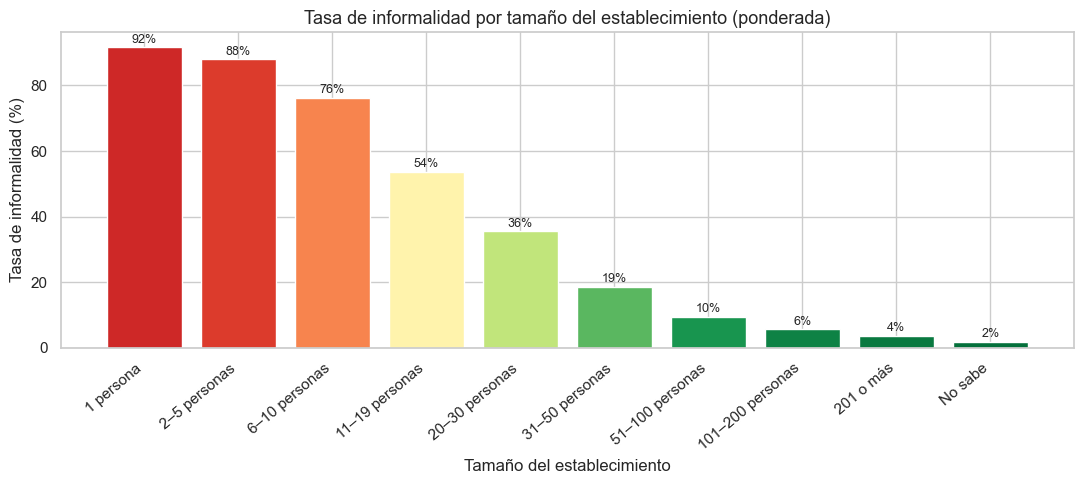

In [84]:
labels_tamano = {
    1:  '1 persona',
    2:  '2–5 personas',
    3:  '6–10 personas',
    4:  '11–19 personas',
    5:  '20–30 personas',
    6:  '31–50 personas',
    7:  '51–100 personas',
    8:  '101–200 personas',
    9:  '201 o más',
    10: 'No sabe',
}

tasa_tam = (
    df_validos[df_validos['P3069'].notna()]
    .groupby('P3069', observed=True)
    .apply(lambda g: (
        (g['INFORMAL'] * g['FEX_C18']).sum() / g['FEX_C18'].sum() * 100
    ), include_groups=False)
    .reset_index()
    .rename(columns={0: 'tasa'})
)
tasa_tam['etiqueta'] = tasa_tam['P3069'].map(labels_tamano)

fig, ax = plt.subplots(figsize=(11, 5))
colors = plt.cm.RdYlGn_r(tasa_tam['tasa'] / 100)
bars = ax.bar(tasa_tam['etiqueta'], tasa_tam['tasa'], color=colors, edgecolor='white')
ax.set_title('Tasa de informalidad por tamaño del establecimiento (ponderada)', fontsize=13)
ax.set_ylabel('Tasa de informalidad (%)')
ax.set_xlabel('Tamaño del establecimiento')
plt.xticks(rotation=40, ha='right')
for bar, val in zip(bars, tasa_tam['tasa']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

---
### Informalidad por sexo (`P3271`) y zona (`CLASE`)

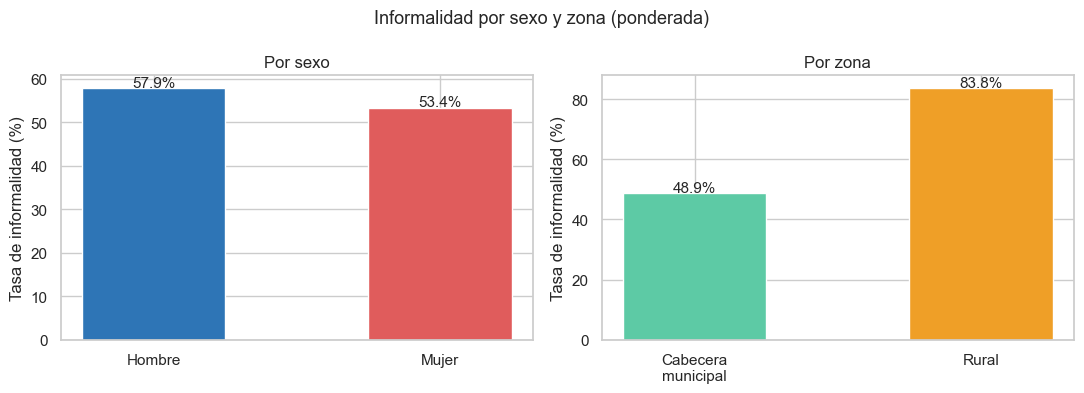

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Por sexo
def tasa_pond(g):
    return (g['INFORMAL'] * g['FEX_C18']).sum() / g['FEX_C18'].sum() * 100

t_sexo = (
    df_validos[df_validos['P3271'].notna()]
    .groupby('P3271', observed=True)
    .apply(tasa_pond, include_groups=False)
    .reset_index()
    .rename(columns={0: 'tasa'})
)
t_sexo['etiqueta'] = t_sexo['P3271'].map({1: 'Hombre', 2: 'Mujer'})

axes[0].bar(t_sexo['etiqueta'], t_sexo['tasa'],
            color=['#2E75B6', '#E05C5C'], edgecolor='white', width=0.5)
axes[0].set_title('Por sexo', fontsize=12)
axes[0].set_ylabel('Tasa de informalidad (%)')
for i, val in enumerate(t_sexo['tasa']):
    axes[0].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=11)

# Por zona
t_zona = (
    df_validos[df_validos['CLASE'].notna()]
    .groupby('CLASE', observed=True)
    .apply(tasa_pond, include_groups=False)
    .reset_index()
    .rename(columns={0: 'tasa'})
)
t_zona['etiqueta'] = t_zona['CLASE'].map({1: 'Cabecera\nmunicipal', 2: 'Rural'})

axes[1].bar(t_zona['etiqueta'], t_zona['tasa'],
            color=['#5DCAA5', '#EF9F27'], edgecolor='white', width=0.5)
axes[1].set_title('Por zona', fontsize=12)
axes[1].set_ylabel('Tasa de informalidad (%)')
for i, val in enumerate(t_zona['tasa']):
    axes[1].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=11)

plt.suptitle('Informalidad por sexo y zona (ponderada)', fontsize=13)
plt.tight_layout()
plt.show()

---
### Informalidad por edad (`P6040`)

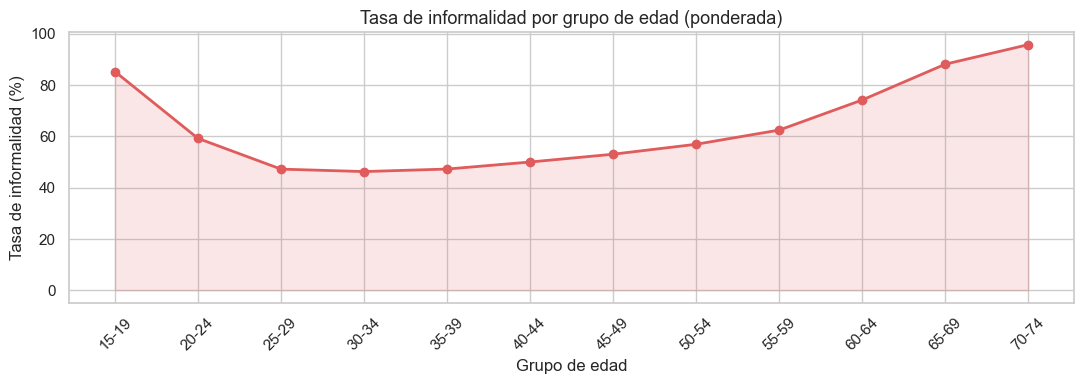

In [86]:
# Agrupar por quinquenios de edad para suavizar la curva
df_validos['EDAD_QUINT'] = pd.cut(
    df_validos['P6040'],
    bins=range(14, 76, 5),
    labels=[f'{i}-{i+4}' for i in range(15, 75, 5)]
)

tasa_edad = (
    df_validos[df_validos['EDAD_QUINT'].notna()]
    .groupby('EDAD_QUINT', observed=True)
    .apply(tasa_pond, include_groups=False)
    .reset_index()
    .rename(columns={0: 'tasa'})
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(tasa_edad['EDAD_QUINT'].astype(str), tasa_edad['tasa'],
        marker='o', color='#E05C5C', linewidth=2, markersize=6)
ax.fill_between(range(len(tasa_edad)), tasa_edad['tasa'],
                alpha=0.15, color='#E05C5C')
ax.set_title('Tasa de informalidad por grupo de edad (ponderada)', fontsize=13)
ax.set_ylabel('Tasa de informalidad (%)')
ax.set_xlabel('Grupo de edad')
ax.set_xticks(range(len(tasa_edad)))
ax.set_xticklabels(tasa_edad['EDAD_QUINT'].astype(str), rotation=45)
plt.tight_layout()
plt.show()

---
### Informalidad por rama de actividad (`RAMA2D_R4`)

In [87]:
# Top 15 ramas por volumen de ocupados
top_ramas = df_validos['RAMA2D_R4'].value_counts().head(15).index

tasa_rama = (
    df_validos[df_validos['RAMA2D_R4'].isin(top_ramas)]
    .groupby('RAMA2D_R4', observed=True)
    .apply(tasa_pond, include_groups=False)
    .reset_index()
    .rename(columns={0: 'tasa'})
    .sort_values('tasa', ascending=True)
)

fig = px.bar(
    tasa_rama, x='tasa', y=tasa_rama['RAMA2D_R4'].astype(str), orientation='h',
    title='Tasa de informalidad — Top 15 ramas de actividad (CIIU 2 dígitos)',
    labels={'tasa': 'Tasa (%)', 'y': 'Rama CIIU'},
    color='tasa', color_continuous_scale='RdYlGn_r',
    text=tasa_rama['tasa'].round(1).astype(str) + '%'
)
fig.update_traces(textposition='outside')
fig.update_layout(coloraxis_showscale=False, height=500)
fig.show()

---
### Distribución de ingresos

=== ESTADÍSTICAS DE INGLABO POR GRUPO ===
             count       mean        std   min        25%        50%        75%        90%          max
INFORMAL                                                                                               
0.0       149220.0  2661434.0  2781374.0  12.0  1423500.0  1800000.0  3000000.0  4900000.0  103000000.0
1.0       192078.0  1060686.0  1138355.0   1.0   500000.0   900000.0  1400000.0  1800000.0   87700000.0


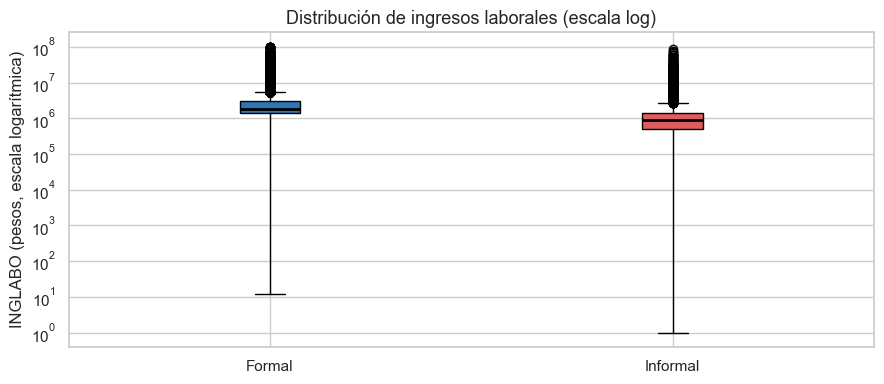

In [88]:
# Solo registros con ingreso positivo declarado
df_ing = df_validos[
    df_validos['INGLABO'].notna() & (df_validos['INGLABO'] > 0)
].copy()

print('=== ESTADÍSTICAS DE INGLABO POR GRUPO ===')
print(df_ing.groupby('INFORMAL')['INGLABO'].describe(
    percentiles=[.25, .5, .75, .9]
).round(0).to_string())

# Boxplot comparativo (log scale para manejar la asimetría)
fig, ax = plt.subplots(figsize=(9, 4))
grupos = [df_ing[df_ing['INFORMAL'] == 0]['INGLABO'],
          df_ing[df_ing['INFORMAL'] == 1]['INGLABO']]
bp = ax.boxplot(grupos, labels=['Formal', 'Informal'],
                patch_artist=True, notch=False,
                medianprops={'color': 'black', 'linewidth': 2})
bp['boxes'][0].set_facecolor('#2E75B6')
bp['boxes'][1].set_facecolor('#E05C5C')
ax.set_yscale('log')
ax.set_title('Distribución de ingresos laborales (escala log)', fontsize=13)
ax.set_ylabel('INGLABO (pesos, escala logarítmica)')
plt.tight_layout()
plt.show()

---
### Correlación entre variables numéricas

Análisis de asociación lineal entre las variables numéricas del dataset.
Útil para detectar multicolinealidad antes del modelado.

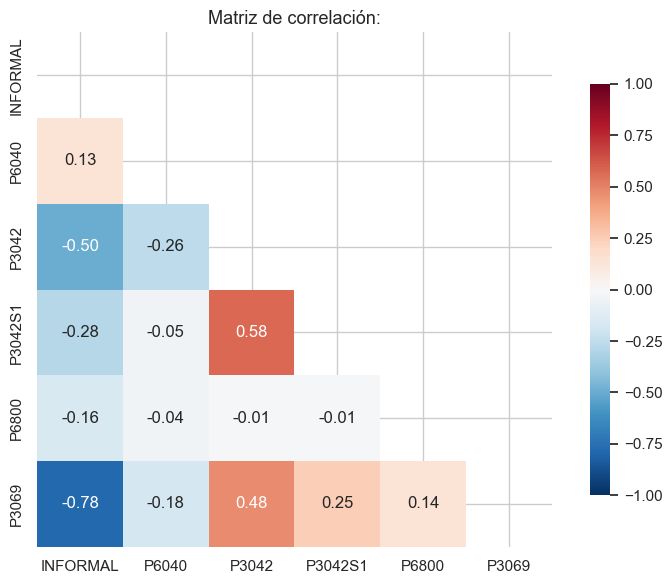


Correlaciones con INFORMAL (variable objetivo):
P3069     -0.782611
P3042     -0.497877
P3042S1   -0.283351
P6800     -0.162201
P6040      0.133013


In [89]:
cols_numericas = ['INFORMAL', 'P6040', 'P3042', 'P3042S1', 'P6800', 'P3069']
cols_presentes = [c for c in cols_numericas if c in df_validos.columns]

corr = df_validos[cols_presentes].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de correlación:', fontsize=13)
plt.tight_layout()
plt.show()

print('\nCorrelaciones con INFORMAL (variable objetivo):')
print(corr['INFORMAL'].drop('INFORMAL').sort_values().to_string())

In [90]:

print(f"""
VARIABLE OBJETIVO:
  • Tasa de informalidad (ponderada): {tasa_ponderada:.1f}%
  • Desbalanceo moderado.
  • Pensionados excluidos: {(df['P6920'] == 3).sum():,} registros (~{(df['P6920'] == 3).sum()/len(df)*100:.1f}%)

RELACIONES DETECTADAS:
  • P6040 (edad): relación no lineal con informalidad
  • P3042 (educación): relación negativa clara con informalidad
  • P6430 (posición): cuenta propia tiene tasa muy alta
  • P3069 (tamaño): microempresas concentran informalidad
  • P6800 (horas): explorar umbral de subempleo
  • P7040 (pluriempleo): 1=Sí, 2=No
  • RAMA2D_R4: alta cardinalidad
  • DPTO: alta cardinalidad

VARIABLES A EXCLUIR DEL MODELO:
  • INGLABO: consecuencia de informalidad
  • P6920: es la fuente de la variable objetivo
""")



VARIABLE OBJETIVO:
  • Tasa de informalidad (ponderada): 56.0%
  • Desbalanceo moderado.
  • Pensionados excluidos: 6,308 registros (~1.8%)

RELACIONES DETECTADAS:
  • P6040 (edad): relación no lineal con informalidad
  • P3042 (educación): relación negativa clara con informalidad
  • P6430 (posición): cuenta propia tiene tasa muy alta
  • P3069 (tamaño): microempresas concentran informalidad
  • P6800 (horas): explorar umbral de subempleo
  • P7040 (pluriempleo): 1=Sí, 2=No
  • RAMA2D_R4: alta cardinalidad
  • DPTO: alta cardinalidad

VARIABLES A EXCLUIR DEL MODELO:
  • INGLABO: consecuencia de informalidad
  • P6920: es la fuente de la variable objetivo

